### Advection — GRAPEX patchy irrigation

This notebook solves the Sutton advection problem for **water vapour only** over a landscape of alternating irrigated (crop) and fallow strips, motivated by the GRAPEX vineyard experiment.

**Setup**
- Domain: 1 km × 100 m, `dx = 5 m`, `dz = 0.5 m`, `zom = 0.22 m` (both surfaces)
- Wind: log-law profile from `U_10 = 4 m/s`
- Surface moisture: `Q_c` (crop, RH 42 % at 30 °C), `Q_f` (fallow, RH 12 % at 50 °C)
- Canopy height `h = 2.3 m`; mixing length clipped inside canopy

**Method**
- Implicit x-marching scheme using `integrate_H2O_implicit` (Thomas algorithm) from the `sutton` package
- Three runs: (1) patchy surface (`varying_Qs`), (2) uniform crop (`uniform_cultivated`), (3) uniform fallow (`uniform_fallow`)
- `ET_enhance` computes the advective enhancement of ET relative to continuous cultivation

**Outputs**
- Surface flux transects (g m⁻² s⁻¹ and W m⁻²)
- 2-D contour plots of water-vapour concentration and vertical flux
- Normalised concentration field $(Q - Q_a)/(Q_c - Q_a)$

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import numpy as np
sys.path.append("../src")

            
from sutton import *

In [20]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import sys
import math

CPU times: user 9 µs, sys: 0 ns, total: 9 µs
Wall time: 11.9 µs


In [4]:
from sutton import Params, saturation_vapor_pressure, vapor_concentration_RH
import numpy as np
import math

def get_params(fallow_fraction = 0., fallow_length = 1000, T_c = 30, T_f = 50):
    zom = 0.22
    p = Params(Lx=1000, Hmax=100, dz=0.5, dx=5, zom_f=zom, zom_c=zom)
    d = p.to_dict()
    # Legacy fields
    Ubar_10 = 4.0
    ustar = d['k']*Ubar_10/np.log(10.0/zom)
    d.update({
        'zom': zom,
        'ustar': ustar,
        'xmin': 0,
        'xmax': d['Lx'],
        'zmin': zom,
        'zmax': d['Hmax'],
    })
    # Surface Q from physics helpers
    RH_c = 42
    es_c = saturation_vapor_pressure(T_c + 273.15)
    Q_c = vapor_concentration_RH(T_c, RH_c)
    RH_f = 12
    es_f = saturation_vapor_pressure(T_f + 273.15)
    Q_f = vapor_concentration_RH(T_f, RH_f)
    Q_a = vapor_concentration_RH(T_f, 11.5)
    d['Q_c'] = Q_c
    d['Q_f'] = Q_f
    d['Q_a'] = Q_a
    # Sizes
    field_size = int(fallow_length/d['dx'])
    gap_size = int(field_size*(1-fallow_fraction)/fallow_fraction) if fallow_fraction>0 else 0
    d['field_size'] = field_size
    d['gap_size'] = gap_size
    # Grid counts to match notebook usage
    z = np.arange(d['zmin'] + d['dz'], d['zmax'] + d['dz'], d['dz'])
    x = np.arange(d['xmin'], d['xmax'] + d['dx'], d['dx'])
    d['nz'] = len(z)
    d['nx'] = len(x)
    return d

In [5]:
def populate_Qc_array(params):
    # Retrieve parameters from the dictionary
    x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])
    nx = len(x)
    field_size = params["field_size"]
    gap_size = params["gap_size"]
    Q_c = params["Q_c"]
    Q_f = params["Q_f"]
    
    # Initialize the array with zeros or any other default value
    Q_c_array = [0] * (nx)
    # Populate the array with alternating fieldes
    i = 0
    while i < nx :
        # Assign a vegetated field (Q_c) of fixed length
        Q_c_array[i:i + field_size+1] = [Q_c] * min(field_size, nx  - i)
        i += field_size
        
        # Assign a fallow field (Qf) of fixed length, if within bounds

        Q_c_array[i:i + gap_size] = [Q_f] * min(gap_size, nx  - i)
        i += gap_size
            
    return np.array(Q_c_array)



In [6]:
params = get_params()

# Call the function with the parameter dictionary
Qs_array = populate_Qc_array(params)

ustar = params['ustar']
k = params['k']
Hmax = params['Hmax']
zom = params['zom']
Q_a = params['Q_a']
Q_c = params['Q_c']
Q_f = params['Q_f']
z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
dz = params['dz']
dx = params['dx']

nx = params['nx']
nz = params['nz']

# check these equations
LE_c = ustar*k*(Q_c - Q_a)/np.log(Hmax/zom)  # m/s g/m3 = g /m2 s
LE_f = ustar*k*(Q_f - Q_a)/np.log(Hmax/zom)

# Specify upwind wv concentration (as background)
Qup_f = Q_f - LE_f/(k*ustar)*np.log(z/zom)
# Qup = np.ones_like(z) * Q_a

# Generate the mean velocity profile from the log-law
U = (ustar / k) * np.log(z / zom)

In [7]:
def varying_Qs(nx, nz, dx, dz, k, z, ustar, U, Qup_f, Qs_array, Q_a, h):
    
    # Setup coefficients for the implicit scheme
    zom = h/10
    d = 2/3*h
    # Setup coefficients for the implicit scheme
    lm = k * (z - d)    # mixing length
    lm[z < h] = k*h/3
    
    A = lm * ustar
    B = 1.0 / U
    C = our_central_difference(A, dz)

    # Initialize upwind water vapor concentrations and fluxes
    Q1 = Qup_f
    Q = np.zeros((nx, nz))
    Q[0, :] = Q1
    FluxQ = np.zeros((nx, nz))

    # Perform downwind calculations by marching along x
    for i, Qs_i in enumerate(Qs_array):

        Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Qs_i, Q_a, z)
        Q[i , :] = Q2
        FluxQ[i , :] = Fq

        Q1 = Q2

    return Q, FluxQ

def uniform_cultivated(nx, nz, dx, dz, k, z, ustar, U, Qup_f, Q_c, Q_a, h):

    zom = h/10
    d = 2/3*h
    # Setup coefficients for the implicit scheme
    lm = k * (z - d)    # mixing length
    lm[z < h] = k*h/3
    
    A = lm * ustar
    B = 1.0 / U
    C = our_central_difference(A, dz)

    # Upwind wv concentrations and fluxes
    Q1 = Qup_f
    Q_uniform = np.zeros((nx , nz))
    Q_uniform[0, :] = Q1
    FluxQ_uniform = np.zeros((nx , nz))

    # Begin downwind calculations by marching along x
    for i in range(nx):
        Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Q_c, Q_a, z)
        Q_uniform[i, :] = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2

    return Q_uniform, FluxQ_uniform

def uniform_fallow(nx, nz, dx, dz, k, z, ustar, U, Qup_f, Q_f, Q_a, h):
    
    zom = h/10
    d = 2/3*h
    # Setup coefficients for the implicit scheme
    lm = k * (z - d)    # mixing length
    lm[z < h] = k*h/3
    
    A = lm * ustar
    B = 1.0 / U
    C = our_central_difference(A, dz)    
    
    # Upwind wv concentrations and fluxes
    Q1 = Qup_f
    Q_fallow = np.zeros((nx , nz))
    Q_fallow[0, :] = Q1
    FluxQ_fallow = np.zeros((nx , nz))
    
    # Begin downwind calculations by marching along x
    for i in range(nx):
        Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Q_f, Q_a, z)

        Q_fallow[i, :] = Q2
        FluxQ_fallow[i, :] = Fq
        Q1 = Q2

    return Q_fallow, FluxQ_fallow

def ET_enhance(FluxQ_uniform, FluxQ_fallow, FluxQ):
    
    continuous_cultivation = FluxQ_uniform[nx-1, 0]*dx
    
    uniform_flux = FluxQ_uniform[nx-1, 0]*(Qs_array > Q_f).mean() + \
                FluxQ_fallow[nx-1, 0]*(Qs_array == Q_f).mean()
    uniform_flux = uniform_flux*dx
    
    FluxQ_force = FluxQ.copy()
    FluxQ_force[Qs_array < Q_c] = FluxQ_fallow[-1,0]
    
    return  continuous_cultivation, uniform_flux, FluxQ_force[:, 0].mean()*dx


In [8]:
h = 2.3
irg_ind = 2
Q, FluxQ = varying_Qs(nx, nz, dx, dz, k, z, ustar, U, Qup_f, Qs_array, Q_a, h)
    
Q_uniform, FluxQ_uniform = uniform_cultivated(nx, nz, dx, dz, k, z, ustar, U, Qup_f, Q_c, Q_a, h)
Q_fallow, FluxQ_fallow = uniform_fallow(nx, nz, dx, dz, k, z, ustar, U, Qup_f, Q_f, Q_a, h)        
    
continuous_cultivation, uniform_flux, patchy_flux = ET_enhance(FluxQ_uniform, FluxQ_fallow, FluxQ)    
FluxQ[Qs_array < Q_c] = FluxQ_fallow[-1,0]



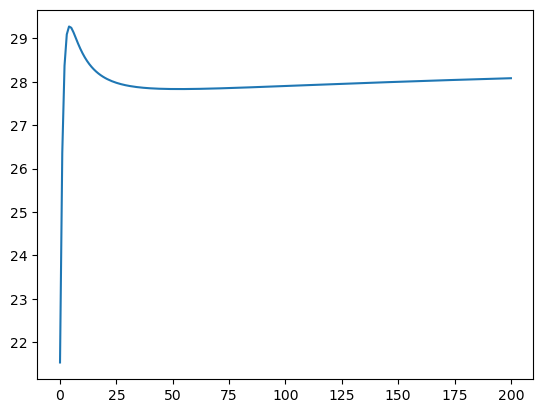

In [9]:
# plt.plot(FluxQ_fallow[:, 0]*2260)
plt.plot(FluxQ_fallow[:, irg_ind]*2260)

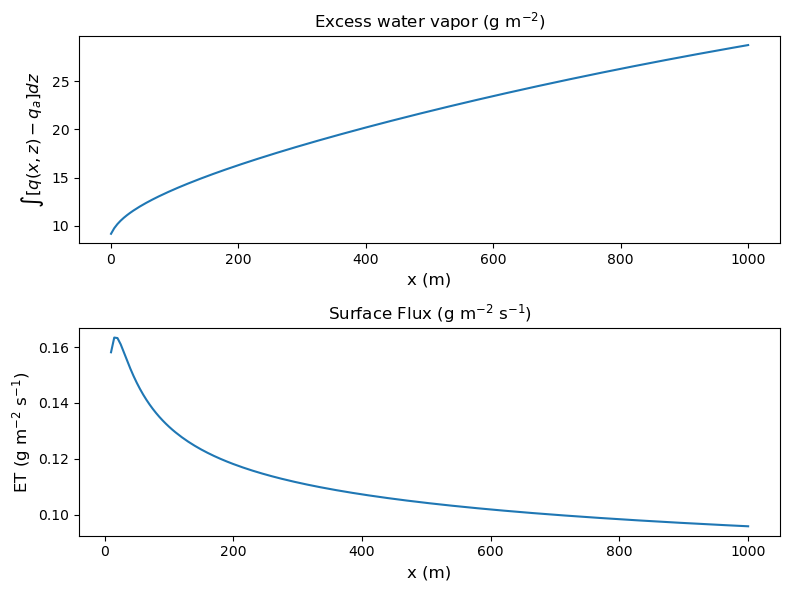

In [10]:
# Plot excess water vapor and surface flux
plt.figure(figsize = (8, 6))
x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])
QQ = np.sum(Q - Q_a, axis=1) * dz
QQ_uniform = np.sum(Q_uniform - Q_a, axis=1) * dz

plt.subplot(2, 1, 1)
plt.plot(x, QQ, '-', label = 'Fallow patches')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel(r'$\int [q(x,z) - q_a]dz$', fontsize=12, fontweight='normal')
plt.title('Excess water vapor (g m$^{-2}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.plot(x[2:], FluxQ[2:, irg_ind], '-')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('ET (g m$^{-2}$ s$^{-1}$)', fontsize=12, fontweight='normal')
plt.title('Surface Flux (g m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()

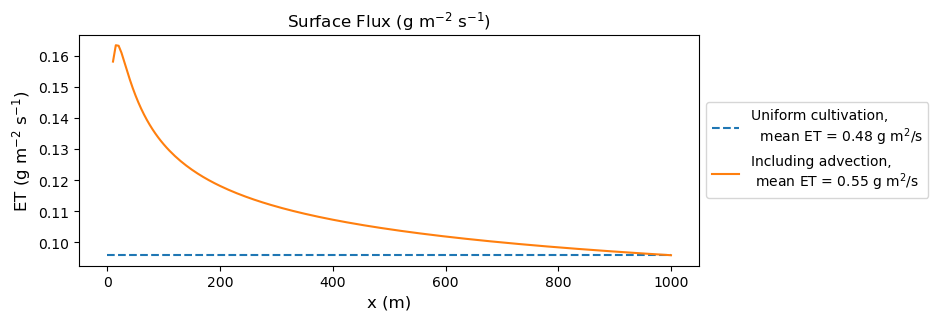

In [11]:
plt.figure(figsize = (8, 3))
ax = plt.gca()

plt.plot(x, np.ones(nx ) * FluxQ_uniform[nx-1, irg_ind], '--',  
         label = "Uniform cultivation, \n  mean ET = {0:.2f} g m$^2$/s".format(
             FluxQ_uniform[nx-1, irg_ind]*dx))


uniform_flux = FluxQ_uniform[nx-1, irg_ind]*(Qs_array > Q_f).mean() + \
                FluxQ_fallow[nx-1, irg_ind]*(Qs_array == Q_f).mean()

plt.plot(x[2:], FluxQ[2:, irg_ind], '-', label = 
    "Including advection,  \n mean ET = {0:.2f} g m$^2$/s".format(FluxQ[2:, irg_ind].mean()*dx))

plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('ET (g m$^{-2}$ s$^{-1}$)', fontsize=12, fontweight='normal')
plt.title('Surface Flux (g m$^{-2}$ s$^{-1}$)', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


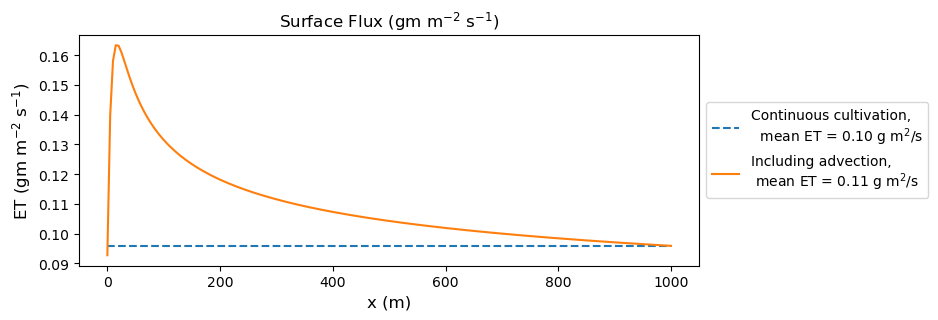

In [12]:

plt.figure(figsize = (8, 3))
ax = plt.gca()

plt.plot(x, np.ones(nx ) * FluxQ_uniform[nx-1, irg_ind], '--',  
         label = "Continuous cultivation, \n  mean ET = {0:.2f} g m$^2$/s".format(
             FluxQ_uniform[nx-1, irg_ind]))


# FluxQ[Qs_array < Q_c] = FluxQ_fallow[-1,0]
plt.plot(x[:], FluxQ[:, irg_ind], '-', label = "Including advection,  \n mean ET = {0:.2f} g m$^2$/s".format(
    FluxQ[:, irg_ind].mean()))

plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('ET (gm m$^{-2}$ s$^{-1}$)', fontsize=12, fontweight='normal')
plt.title('Surface Flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# (FluxQ[:, 0].sum()*dx/nx - FluxQ[nx:,  0].sum()*dx)/(FluxQ[nx:,  0].sum()*dx)

In [13]:
irg_ind

2

(0.0, 386.3252247672008)

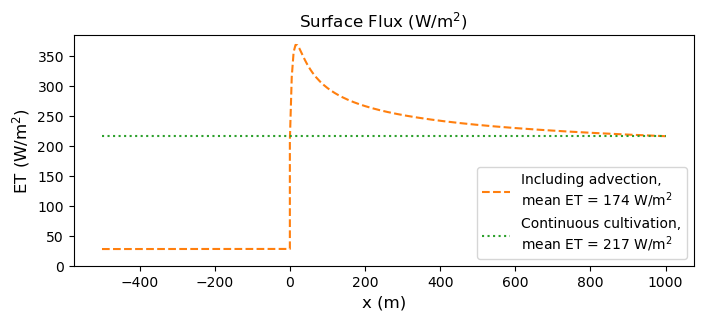

In [14]:


plt.figure(figsize = (8, 3))
ax = plt.gca()

x_combined = np.concatenate([ -  np.flip(x[:-100]) ,x])
flux_combined = np.concatenate([FluxQ_fallow[100:, irg_ind] * 2260, FluxQ[:, irg_ind] * 2260])

plt.plot(
    x_combined, 
    flux_combined, 
    '--', c  = 'C1',
    label=f"Including advection,\nmean ET = {flux_combined.mean():.0f} W/m$^2$"
)

x_combined = np.concatenate([ -  np.flip(x[:-100]) ,x])
flux_combined = np.ones_like(x_combined) * FluxQ_uniform[nx-1, irg_ind]*2260

plt.plot(
    x_combined, 
    flux_combined, ':', c = 'C2',
    label=f"Continuous cultivation,\nmean ET = {flux_combined.mean():.0f} W/m$^2$"
)

plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('ET (W/m$^2$)', fontsize=12, fontweight='normal')
plt.title('Surface Flux (W/m$^2$)', fontsize=12)
ax.legend()#loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylim(0, )
# (FluxQ[2:, irg_ind].sum()*dx/nx - FluxQ[nx:,  irg_ind].sum()*dx)/(FluxQ[nx:,  irg_ind].sum()*dx)


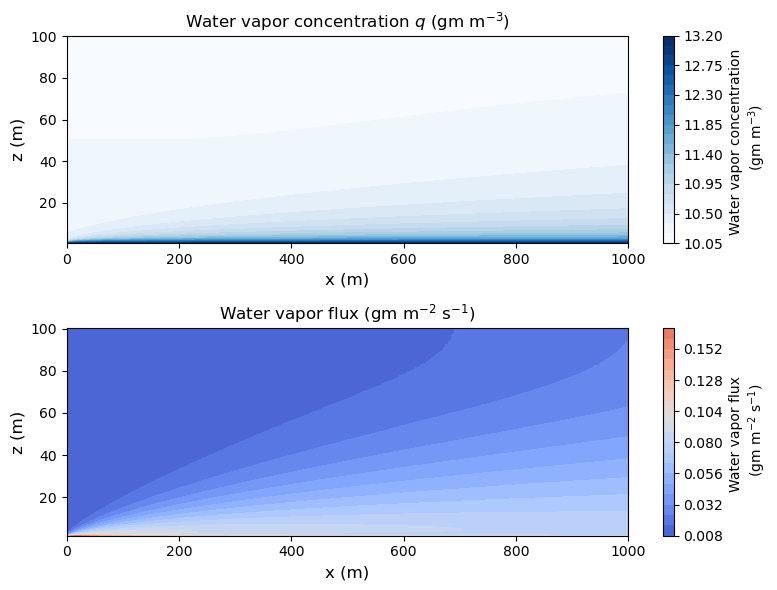

In [15]:

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q_uniform.T), 25, cmap='Blues',  vmax = Q_c, vmin = Q_a)
plt.colorbar(label='Water vapor concentration \n (gm m$^{-3}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (gm m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x, z[2:], FluxQ_uniform.T.round(4)[ 2:],  20, cmap='coolwarm', vmin = 0, vmax = 0.2)
plt.colorbar(label='Water vapor flux \n (gm m$^{-2}$ s$^{-1}$)') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()



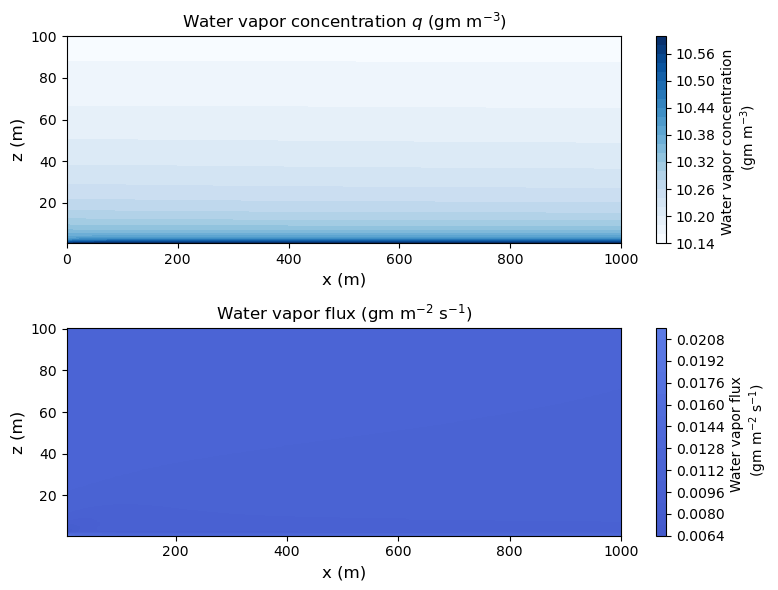

In [16]:

z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q_fallow.T), 25, cmap='Blues',  vmax = Q_f, vmin = Q_a)
plt.colorbar(label='Water vapor concentration \n (gm m$^{-3}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (gm m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x[1:], z, FluxQ_fallow[1:].T.round(4),  20, cmap='coolwarm', vmin =0, vmax = 0.2)
plt.colorbar(label='Water vapor flux \n (gm m$^{-2}$ s$^{-1}$)') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()


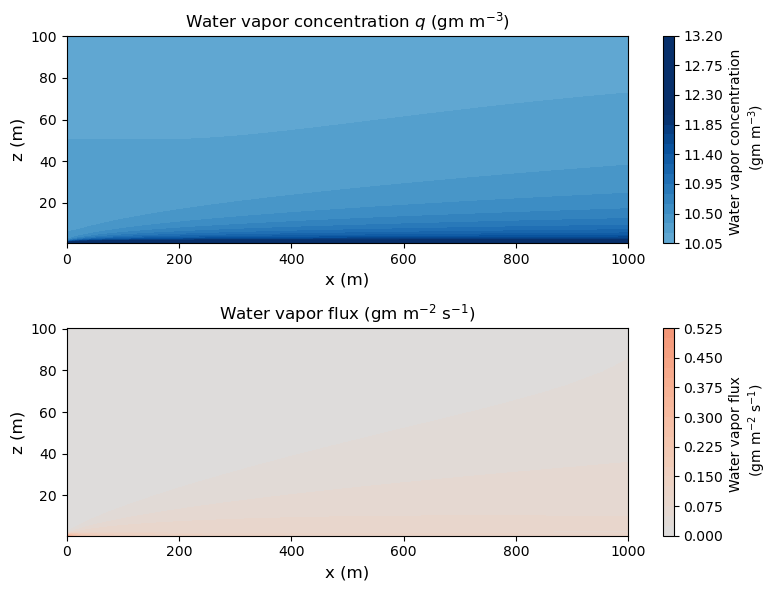

In [17]:
# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

# Normalized concentration (if needed)
# Qd = (Q - Qa) / (Qs - Qa)

plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q.T), 25, cmap='Blues',  vmax = 12, vmin = 8)
plt.colorbar(label='Water vapor concentration \n (gm m$^{-3}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (gm m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x, z, FluxQ.T.round(4),  20, cmap='coolwarm', vmin = -1, vmax = 1)
plt.colorbar(label='Water vapor flux \n (gm m$^{-2}$ s$^{-1}$)') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'y=(Q-Q_a)/(Q_s-Q_a)')

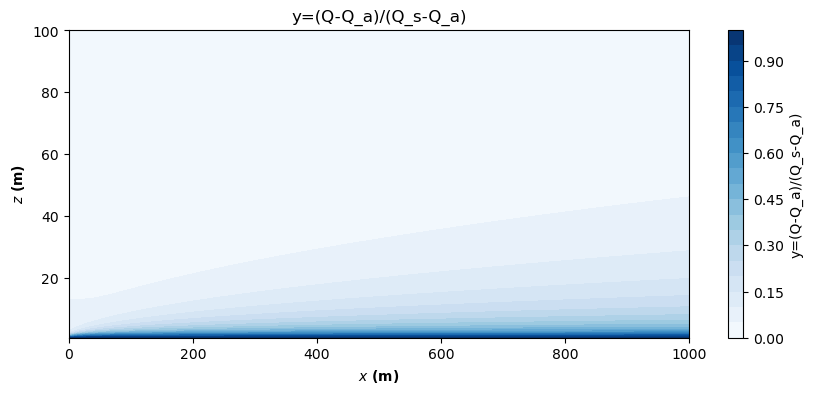

In [18]:

# Normalized concentration
Q_d = (Q - Q_a) / (Q_c - Q_a)

plt.figure(3, figsize = (10,4))
plt.clf()
plt.contourf(x, z, Q_d.T, 20, vmax =1, cmap='Blues')
plt.xlabel(r'$\it{x}$ (m)', fontweight='bold', fontsize=10)
plt.ylabel(r'$\it{z}$ (m)', fontweight='bold', fontsize=10)
plt.colorbar(label='y=(Q-Q_a)/(Q_s-Q_a)')
plt.title('y=(Q-Q_a)/(Q_s-Q_a)')
